<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_3/blob/main/17_2_4_THEORY_Using_Word_Embeddings_for_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
In this notebook we will perform sentiment analysis on tweets. To that end, we will:
* use the Embedding layer of Keras to create word embeddings from the training data
* use pretrained word embeddings trained on a much larger corpus

# Word Embeddings
When applying one-hot encoding to the words in the tweets, we end up with **sparse** vectors of high dimensionality (here, the number of words). On larger data sets this could cause performance issues. Additionally, one-hot encoding does not take into account the semantics of the words. For instance, *plane* and *aircraft* are different words but have a similar meaning.

Word embeddings reduce these two issues. Word embeddings are **dense** vectors with a much lower dimensionality. Secondly, the semantic relationships between words are reflected in the distance and direction of the vectors.  

# Set-up of the project

In [ ]:
# Basic packages
import pandas as pd
import numpy as np
import re
import collections
import matplotlib.pyplot as plt
from pathlib import Path

# Packages for data preparation
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Packages for modeling
import keras
from keras import models
from keras import layers
from keras import regularizers

In [ ]:
NB_WORDS = 10000  # Parameter indicating the number of words we'll put in the dictionary
VAL_SIZE = 1000  # Size of the validation set
NB_START_EPOCHS = 10  # Number of epochs we usually start to train with
BATCH_SIZE = 512  # Size of the batches used in the mini-batch gradient descent
MAX_LEN = 24  # Maximum number of words in a sequence
GLOVE_DIM = 100  # Number of dimensions of the GloVe word embeddings

In [ ]:
!gdown -O Tweets.csv 17B2dhbnyuU-W5WLFzjH0Ta1CTETmWzsR

Downloading...
From: https://drive.google.com/uc?id=17B2dhbnyuU-W5WLFzjH0Ta1CTETmWzsR
To: /content/Tweets.csv
100% 3.42M/3.42M [00:00<00:00, 39.2MB/s]


In [ ]:
full_df = pd.read_csv('Tweets.csv') # .airline.unique()

In [ ]:
root = Path('../')
input_path = Path('./')
ouput_path = root / 'output/'
source_path = root / 'source/'

# Some helper functions

In [ ]:
def eval_metric(history, metric_name):
    '''
    Function to evaluate a trained model on a chosen metric.
    Training and validation metric are plotted in a
    line chart for each epoch.

    Parameters:
        history : model training history
        metric_name : loss or accuracy
    Output:
        line chart with epochs of x-axis and metric on
        y-axis
    '''
    metric = history.history[metric_name]
    val_metric = history.history['val_' + metric_name]

    e = range(1, len(metric) + 1)

    plt.plot(e, metric, 'bo', label='Train ' + metric_name)
    plt.plot(e, val_metric, 'b', label='Validation ' + metric_name)
    plt.legend()
    plt.show()

def test_model(model, X_test, y_test):
    '''
    Function to test the model

    Parameters:
        model : trained model
        X_test : test features
        y_test : test target
    Output:
        test accuracy and test loss
    '''
    results = model.evaluate(X_test, y_test)
    return results

def remove_stopwords(input_text):
    '''
    Function to remove English stopwords from a Pandas Series.

    Parameters:
        input_text : text to clean
    Output:
        cleaned Pandas Series
    '''
    stopwords_list = stopwords.words('english')
    # Some words which might indicate a certain sentiment are kept via a whitelist
    whitelist = ["n't", "not", "no"]
    words = input_text.split()
    clean_words = [word for word in words if (word not in stopwords_list or word in whitelist) and len(word) > 1]
    return " ".join(clean_words)

def remove_mentions(input_text):
    '''
    Function to remove mentions, preceded by @, in a Pandas Series

    Parameters:
        input_text : text to clean
    Output:
        cleaned Pandas Series
    '''
    return re.sub(r'@\w+', '', input_text)

# Data Preparation
### Reading and cleaning data

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_csv(input_path / 'Tweets.csv')
df = df.reindex(np.random.permutation(df.index))
df = df[['text', 'airline_sentiment']]
df.text = df.text.apply(remove_stopwords).apply(remove_mentions)

In [ ]:
df.head()

,text,airline_sentiment
11486,Is way someone contact agent available? Need ...,negative
8505,Walked hall Carousel 8...found bags sitting t...,negative
4603,thinks $100 voucher makes spending hrs plane ...,negative
3701,"#1007 Houston-Bogota engine problem, mechanic...",negative
5489,"son flying South West NOLA-Orlando, hope ente...",neutral


### Train-Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.text, df.airline_sentiment, test_size=0.1, random_state=37)
print('# Train data samples:', X_train.shape[0])
print('# Test data samples:', X_test.shape[0])
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]

# Train data samples: 13176
# Test data samples: 1464


In [ ]:
print(len(X_train), len(y_train))

13176 13176


Let's examine some "clean" tweets:

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

@interact(i=widgets.IntSlider(min=0, max=len(X_train), value=0))
def show_x_y(i):
    print(f"({y_train.iloc[i]}): {X_train.iloc[i]}" )

interactive(children=(IntSlider(value=0, description='i', max=13176), Output()), _dom_classes=('widget-interac…

### Converting words to numbers

In [ ]:
tk = Tokenizer(num_words=NB_WORDS,
               filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
               lower=True,
               split=" ")
tk.fit_on_texts(X_train)

X_train_seq = tk.texts_to_sequences(X_train)
X_test_seq = tk.texts_to_sequences(X_test)

### Creating word sequences of equal length
Before we can compute the word embeddings, we need to make sure the sequences are of equal length. In the example below, we truncate sequences to length MAX_LEN, or pad them with zeroes to achieve this. First, we'll have a look at the length of the (cleaned) tweets.

In [ ]:
seq_lengths = X_train.apply(lambda x: len(x.split(' ')))
seq_lengths.describe()

,text
count,13176.000000
mean,11.147617
std,4.213846
min,1.000000
25%,8.000000
50%,12.000000
75%,14.000000
max,24.000000


Based on the figures above we will set MAX_LEN to 24. So this means we will not be truncating any words, only pad with zeros. This is to avoid losing information as the tweets are rather short.

In [ ]:
X_train_seq_trunc = pad_sequences(X_train_seq, maxlen=MAX_LEN)
X_test_seq_trunc = pad_sequences(X_test_seq, maxlen=MAX_LEN)

In [ ]:
X_train_seq_trunc[10]  # Example of padded sequence

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,  941,
        135,   72,  410,   55,   77,  236, 6056, 6057, 6058,   45, 4294,
         12, 1674], dtype=int32)

### Converting the target classes to numbers

In [ ]:
le = LabelEncoder()
y_train_le = le.fit_transform(y_train)
y_test_le = le.transform(y_test)
y_train_oh = to_categorical(y_train_le)
y_test_oh = to_categorical(y_test_le)

In [ ]:
y_train_le

array([0, 1, 1, ..., 2, 2, 0])

### Splitting off validation data

In [ ]:
X_train_emb, X_valid_emb, y_train_emb, y_valid_emb = train_test_split(X_train_seq_trunc, y_train_oh, test_size=0.1, random_state=37)

assert X_valid_emb.shape[0] == y_valid_emb.shape[0]
assert X_train_emb.shape[0] == y_train_emb.shape[0]

print(f'Shape of validation set: {X_valid_emb.shape = }')

Shape of validation set: X_valid_emb.shape = (1318, 24)


# Modeling

### Training word embeddings
Keras provides an **Embedding layer** which helps us to train specific word embeddings based on our training data. It will convert the words in our vocabulary to multi-dimensional vectors.

In [ ]:
emb_model = models.Sequential()
emb_model.add(layers.Input(shape=(MAX_LEN,)))
emb_model.add(layers.Embedding(NB_WORDS, 8))
emb_model.add(layers.Flatten())
emb_model.add(layers.Dense(3, activation='softmax'))
emb_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 24, 8)          │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           579 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,579 (314.76 KB)

 Trainable params: 80,579 (314.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
emb_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

emb_history = emb_model.fit(X_train_emb
                       , y_train_emb
                       , epochs=300 #NB_START_EPOCHS
                       , batch_size=BATCH_SIZE
                       , validation_data=(X_valid_emb, y_valid_emb)
                       , verbose=1)

emb_history.history['accuracy'][-1]

Epoch 1/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3868 - loss: 1.0942 - val_accuracy: 0.5220 - val_loss: 1.0795
Epoch 2/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5706 - loss: 1.0706 - val_accuracy: 0.6343 - val_loss: 1.0548
Epoch 3/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6187 - loss: 1.0474 - val_accuracy: 0.6563 - val_loss: 1.0283
Epoch 4/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6226 - loss: 1.0233 - val_accuracy: 0.6571 - val_loss: 1.0008
Epoch 5/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6230 - loss: 0.9995 - val_accuracy: 0.6571 - val_loss: 0.9743
Epoch 6/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6230 - loss: 0.9776 - val_accuracy: 0.6571 - val_loss: 0.9498
Epoch 7/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6229 - loss: 0.9587 - val_accuracy: 0.6571 - val_loss: 0.9299
Epoch 8/300
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6230 - loss: 0.9437 - val_accuracy: 0.6571 - 

0.9440040588378906

We have a validation accuracy of about 79%. The number of words in the tweets is rather low, so this result is rather good.

By comparing the training and validation accuracy and loss, we see that the model starts overfitting from epoch 6.

In [ ]:
len(emb_history.history['accuracy'])
len(emb_history.history['val_accuracy'])

300

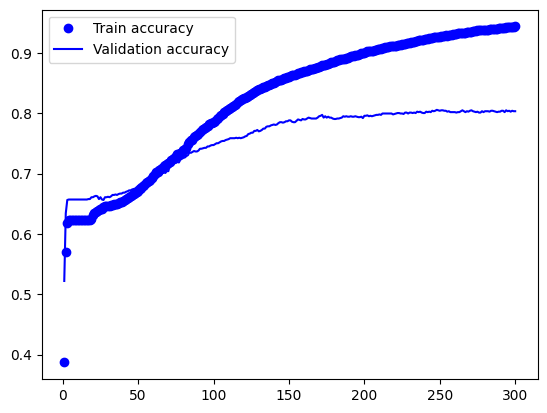

In [ ]:
eval_metric(emb_history, 'accuracy')

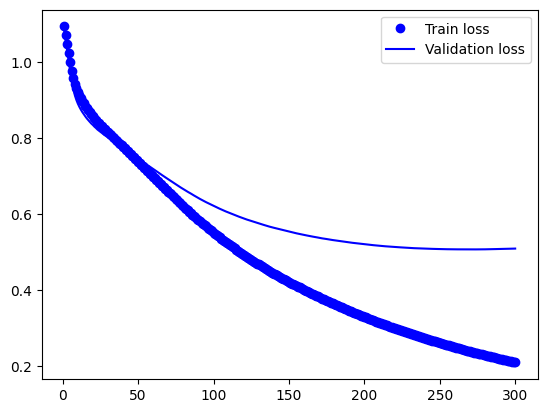

In [ ]:
eval_metric(emb_history, 'loss')

In [ ]:
emb_results = test_model(emb_model, X_test_seq_trunc, y_test_oh)
print('/n')
print('Test accuracy of word embeddings model: {0:.2f}%'.format(emb_results[1]*100))

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7753 - loss: 0.5493
/n
Test accuracy of word embeddings model: 77.53%


This test result is quite ok, but let's see if we can improve it with **pretrained word embeddings**.

### Using pre-trained word embeddings
Because the training data is not so big, the model might not be able to learn good embeddings for the sentiment analysis. Luckily we can load pre-trained word embeddings built on a much larger training data.

The [GloVe database](https://nlp.stanford.edu/projects/glove/) contains multiple pre-trained word embeddings, and more specific embeddings trained on tweets.

In [ ]:
# Uncomment this to download the embeddings!
# !wget http://nlp.stanford.edu/data/glove.twitter.27B.zip

In [ ]:
# !unzip glove*.zip

In [ ]:
glove_file = 'glove.twitter.27B.' + str(GLOVE_DIM) + 'd.txt'
emb_dict = {}
glove = open(input_path / glove_file)
for line in glove:
    values = line.split()
    word = values[0]
    vector = np.asarray(values[1:], dtype='float32')
    emb_dict[word] = vector
glove.close()

FileNotFoundError: [Errno 2] No such file or directory: 'glove.twitter.27B.100d.txt'

Let's test if we can find some airline related words in the dictionary.

In [ ]:
airline_words = ['airplane', 'airline', 'flight', 'luggage']
for w in airline_words:
    if w in emb_dict.keys():
        print(f'Found the word {w} in the dictionary')

To feed this into an Embedding layer, we need to build a matrix containing the words in the tweets and their representative word embedding. So this matrix will be of shape (NB_WORDS, GLOVE_DIM)

In [ ]:
emb_matrix = np.zeros((NB_WORDS, GLOVE_DIM))

for w, i in tk.word_index.items():
    # The word_index contains a token for all words of the training data so we need to limit that
    if i < NB_WORDS:
        vect = emb_dict.get(w)
        # Check if the word from the training data occurs in the GloVe word embeddings
        # Otherwise the vector is kept with only zeros
        if vect is not None:
            emb_matrix[i] = vect
    else:
        break

In [ ]:
glove_model = models.Sequential()
glove_model.add(layers.Input(shape=(MAX_LEN,)))
glove_model.add(layers.Embedding(NB_WORDS, GLOVE_DIM))
glove_model.add(layers.Flatten())
glove_model.add(layers.Dense(3, activation='softmax'))
glove_model.summary()

With the `.set_weights` method we load the pre-trained embeddings in the Embedding layer (here, layer 0). By setting the `trainable` attribute to `False`, we make sure not to change the pre-trained embeddings.

In [ ]:
glove_model.layers[0].set_weights([emb_matrix])
glove_model.layers[0].trainable = False

In [ ]:
glove_model.summary()

In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
emb_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

glove_history = glove_model.fit(X_train_emb
                       , y_train_emb
                       , epochs=100 #NB_START_EPOCHS
                       , batch_size=BATCH_SIZE
                       , validation_data=(X_valid_emb, y_valid_emb)
                       , verbose=1)

glove_history.history['accuracy'][-1]

In [ ]:
eval_metric(glove_history, 'loss')

In [ ]:
eval_metric(glove_history, 'accuracy')

In [ ]:
glove_results = test_model(glove_model, X_test_seq_trunc, y_test_oh)
print('/n')
print('Test accuracy of word glove model: {0:.2f}%'.format(glove_results[1]*100))

The model overfits fast. Moreover the test accuracy is lower compared to the embeddings trained on the training data.

As a final exercise, let's see what results we get when we train the embeddings with the same number of dimensions as the GloVe data.

### Training word embeddings with more dimensions

In [ ]:
emb_model2 = models.Sequential()
emb_model2.add(layers.Input(shape=(MAX_LEN,)))
emb_model2.add(layers.Embedding(NB_WORDS, GLOVE_DIM))
emb_model2.add(layers.Flatten())
emb_model2.add(layers.Dense(3, activation='softmax'))
emb_model2.summary()

In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
emb_model2.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

emb_history2 = emb_model2.fit(X_train_emb
                       , y_train_emb
                       , epochs=100 #NB_START_EPOCHS
                       , batch_size=BATCH_SIZE
                       , validation_data=(X_valid_emb, y_valid_emb)
                       , verbose=1)

emb_history2.history['accuracy'][-1]

In [ ]:
eval_metric(emb_history2, 'loss')

In [ ]:
eval_metric(emb_history2, 'accuracy')

In [ ]:
emb_results2 = test_model(emb_model2, X_test_seq_trunc, y_test_oh)
print('/n')
print('Test accuracy of word embedding model 2: {0:.2f}%'.format(emb_results2[1]*100))

### Conclusion
We achieved the best results with word embeddings that are trained on the available data. Performance doesn't get affected significantly by the dimension of the embedding. This even outperforms the use of word embeddings that were trained on a much larger Twitter corpus.
